# Functions: Domain, Range, and the Common Families

**This notebook teaches functions from scratch, no prior exposure is assumed.**

A **function** is a rule that takes an input and produces exactly **one** output, think of it as a little machine: you feed in a number, and it returns a number. A dose of a drug produces a blood concentration; a time produces a temperature; an input $x$ produces an output $f(x)$. Functions are how we describe the way one quantity depends on another, and almost everything in calculus is built on them. This notebook introduces what a function is, which inputs it accepts (its **domain**) and which outputs it can produce (its **range**), and the four **families** of functions you will meet again and again.

## Learning objectives

- Define a function and evaluate it on many inputs at once.
- Determine a function's **domain** and **range**, including common restrictions.
- Recognize the **polynomial, exponential, logarithmic, and trigonometric** families by their shapes.

## Background

A **function** $f$ takes each input $x$ and returns exactly one output, written $f(x)$. The set of inputs it is allowed to accept is its **domain**; the set of outputs it can produce is its **range**. "Exactly one output" is the defining rule, a single input can never lead to two different outputs.

Some inputs are simply not allowed, which restricts the domain: you cannot take $\log$ of zero or a negative number, cannot take $\sqrt{}$ of a negative number, and cannot divide by zero. Four families of functions cover most of what we need, each with a characteristic shape:

$$\underbrace{a x^2 + b x + c}_{\text{polynomial}}, \qquad \underbrace{a\,b^{x}}_{\text{exponential}}, \qquad \underbrace{\log_b x}_{\text{logarithm}}, \qquad \underbrace{A\sin(\omega x)}_{\text{trigonometric}}.$$

Roughly: **polynomials** curve smoothly (a parabola), **exponentials** grow (or decay) ever faster, **logarithms** grow ever more slowly and accept only positive inputs, and **trigonometric** functions oscillate up and down forever.

## This notebook covers

1. Evaluating a function.
2. Domain and range, with restrictions.
3. The four families side by side.
4. An interactive plotter (sliders).

**Prerequisites:** none, this notebook starts from scratch.

**Dataset:** none, functions are plotted on a grid of $x$-values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# --- plotting helper: draw x-y graphs like the usual coordinate plane ---
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. Evaluating a function

In Python we write a function with `def`. To *see* a function, we evaluate it at many inputs and plot the results. `np.linspace(-3, 3, 100)` makes a grid of 100 evenly spaced inputs from $-3$ to $3$; applying $f$ to that whole grid gives the matching outputs. (Applying one operation to a whole array at once is a numpy convenience, you can also picture it as evaluating $f$ at each input separately.)

In [2]:
# A simple function: f(x) = x squared.
def f(x):
    return x ** 2

# A grid of 100 x-values from -3 to 3.
x = np.linspace(-3, 3, 100)
y = f(x)

print("f(2) =", f(2))
print("first few outputs:", y[:5])

f(2) = 4
first few outputs: [9.         8.64003673 8.28741965 7.94214876 7.60422406]


## 2. Domain and range

The **domain** is the set of inputs a function will accept; the **range** is the set of outputs it can produce. Often the domain is "all real numbers", but three common operations restrict it:

- $\log(x)$ requires $x > 0$ (the log of zero or a negative is undefined),
- $\sqrt{x}$ requires $x \ge 0$,
- $1/x$ requires $x \ne 0$ (you cannot divide by zero).

The logarithm is the classic example: it simply does not exist for $x \le 0$, so its domain is $x > 0$.

smallest output: -4.61
largest output:  1.61


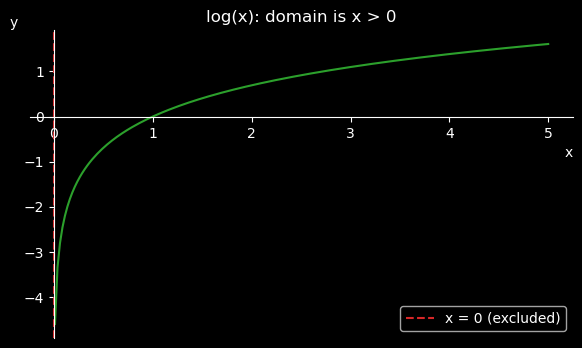

In [3]:
# log(x) is only defined for x > 0, so we keep x positive.
x = np.linspace(0.01, 5, 200)
y = np.log(x)

print("smallest output:", round(float(y.min()), 2))
print("largest output: ", round(float(y.max()), 2))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y, color="tab:green")
ax.axvline(0, color="tab:red", ls="--", label="x = 0 (excluded)")
center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.set_title("log(x): domain is x > 0")
ax.legend()
plt.show()

The curve exists only to the right of $x = 0$ (its domain), and its outputs stretch from very negative upward through all real numbers (its range).

## 3. The four families side by side

Each family has a shape worth memorizing, because you will recognize it in real data again and again. We define one simple version of each and plot all four together.

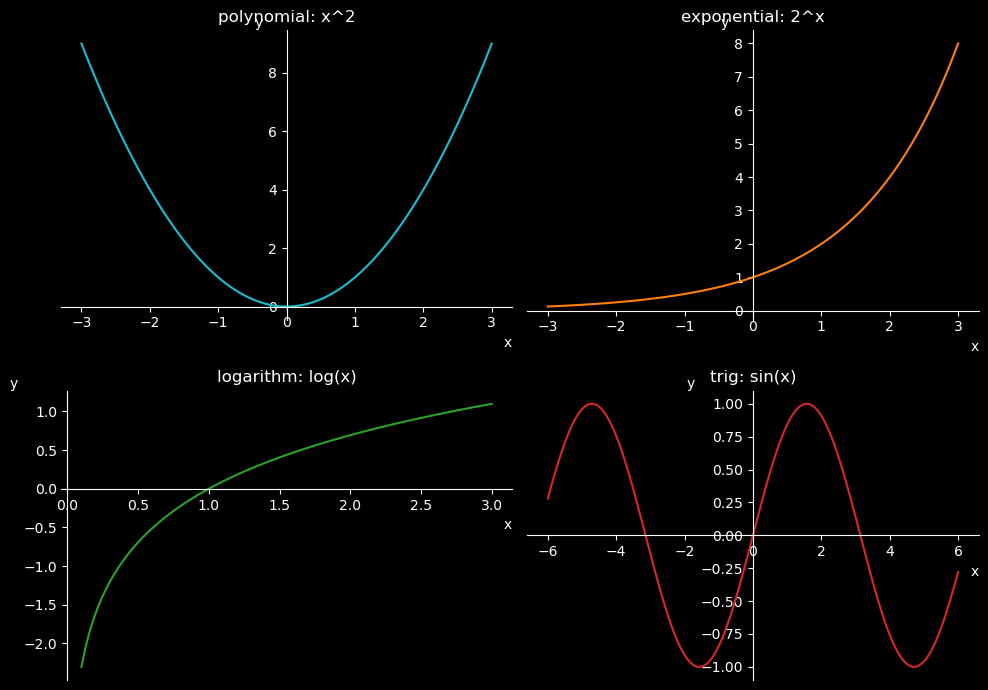

In [4]:
# Simple definitions, one per family.
def polynomial(x):
    return x ** 2

def exponential(x):
    return 2 ** x

def logarithm(x):
    return np.log(x)      # defined only for x > 0

def trig(x):
    return np.sin(x)

# --- graphics: a 2x2 grid of plots (mechanics only) ---
x_all = np.linspace(-3, 3, 100)
x_pos = np.linspace(0.1, 3, 100)     # for the logarithm (needs x > 0)
x_wide = np.linspace(-6, 6, 200)     # for the sine wave

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0, 0].plot(x_all, polynomial(x_all), color="tab:cyan")
axes[0, 0].set_title("polynomial: x^2")
axes[0, 1].plot(x_all, exponential(x_all), color="tab:orange")
axes[0, 1].set_title("exponential: 2^x")
axes[1, 0].plot(x_pos, logarithm(x_pos), color="tab:green")
axes[1, 0].set_title("logarithm: log(x)")
axes[1, 1].plot(x_wide, trig(x_wide), color="tab:red")
axes[1, 1].set_title("trig: sin(x)")

# center and label the axes on every subplot
for ax in axes.flat:
    center_axes(ax)
    ax.set_xlabel("x", loc="right")
    ax.set_ylabel("y", loc="top", rotation=0)

plt.tight_layout()
plt.show()

The polynomial makes a U-shape, the exponential shoots up, the logarithm rises slowly and only exists for $x > 0$, and the sine wave repeats. Recognizing these shapes at a glance is the goal.

## 4. An interactive plotter

Sliders let you change a function's numbers and watch the curve respond. Drag the sliders below to scale ($a$) and stretch ($b$) each family.

*(The slider setup is just plotting machinery, what matters is watching how each number changes the shape.)*

In [5]:
from ipywidgets import interact

# The math is one line: scale the family by a, stretch its input by b.
def plot_family(family="polynomial", a=1.0, b=1.0):
    x = np.linspace(-3, 3, 200)

    if family == "polynomial":
        y = a * (b * x) ** 2
    elif family == "exponential":
        y = a * 2 ** (b * x)
    elif family == "sine":
        y = a * np.sin(b * x)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(x, y, color="tab:cyan")
    center_axes(ax)
    ax.set_xlabel("x", loc="right")
    ax.set_ylabel("y", loc="top", rotation=0)
    ax.set_title(family + ":  a=" + str(a) + ", b=" + str(b))
    ax.set_ylim(-10, 10)
    plt.show()

interact(plot_family,
         family=["polynomial", "exponential", "sine"],
         a=(-3.0, 3.0, 0.5),
         b=(0.5, 3.0, 0.5));

interactive(children=(Dropdown(description='family', options=('polynomial', 'exponential', 'sine'), value='pol…

## 5. Summary

- A **function** maps each input in its **domain** to exactly one output; the outputs form the **range**.
- Watch for restrictions: $\log$ needs $x>0$, $\sqrt{}$ needs $x \ge 0$, $1/x$ needs $x \ne 0$.
- The **polynomial, exponential, logarithm, and trigonometric** families each have a recognizable shape.

Next: combining functions by **composition** (`U1-3_Functions-2_Composition`).